In [ ]:
import pm4py
import pandas as pd
import os

parquet_path = os.path.join("data", "BPI_Challenge_2017.parquet")
df = pd.read_parquet(parquet_path)
log = pm4py.convert_to_event_log(df)

In [ ]:
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator

def calculate_cfc(net):
    """Control-Flow Complexity according to Cardoso (2005).
    XOR-splits (places with >1 out-arc) count as n, AND-splits (transitions with >1 out-arc) count as 1."""
    cfc_xor = sum(len(p.out_arcs) for p in net.places if len(p.out_arcs) > 1)
    cfc_and = sum(1 for t in net.transitions if len(t.out_arcs) > 1)
    return cfc_xor + cfc_and

def calculate_ssa(net):
    unique_labels = {t.label for t in net.transitions if t.label is not None}
    total_nodes = len(net.transitions) + len(net.places)
    return (len(unique_labels) + 2) / total_nodes

def evaluate_model(name, net, im, fm, log):
    """
    Calculate all quality metrics for a given process model.
    
    Parameters:
        name : str        — model name
        net               — Petri net
        im                — initial marking
        fm                — final marking
        log               — event log (DataFrame)

    Returns:
        dict with all metrics
    """
    fitness  = pm4py.fitness_token_based_replay(log, net, im, fm)
    prec     = precision_evaluator.apply(
                    log, net, im, fm,
                    variant=precision_evaluator.Variants.ETCONFORMANCE_TOKEN
               )
    gen      = generalization_evaluator.apply(log, net, im, fm)
    simp     = simplicity_evaluator.apply(net)
    cfc      = calculate_cfc(net)
    ssa      = calculate_ssa(net)
    silent   = sum(1 for t in net.transitions if t.label is None)

    results = {
        "Algorithmus":       name,
        "Places":            len(net.places),
        "Transitions":       len(net.transitions),
        "Silent Trans.":     silent,
        "Arcs":              len(net.arcs),
        "Fitness":           round(fitness['log_fitness'], 4),
        "Precision":         round(prec, 4),
        "Generalization":    round(gen, 4),
        "Simplicity(PM4Py)": round(simp, 4),
        "CFC":               cfc,
        "SSA":               round(ssa, 4),
    }

    # Output
    print(f"\n── {name} ──")
    for key, val in results.items():
        if key != "Algorithmus":
            print(f"{key:<20} {val}")

    return results

# Assignment 3.3 — Final Model Iteration


Filter out cases without complete lifecycle status


In [ ]:
CASE_COL = 'case:concept:name'
ACTIVITY_COL = 'concept:name'
LIFECYCLE_COL = 'lifecycle:transition'

# ── Step 1: Only complete events ─────────────────────────────────────────────
# Assuming the loaded DataFrame is named 'df'
log_complete = df[df[LIFECYCLE_COL] == 'complete'].copy()

print(f"Total events:                    {len(df)}")
print(f"Events removed (non-complete):   {len(df) - len(log_complete)}")
print(f"Events remaining after Step 1:   {len(log_complete)}")

# ── Step 2: Only cases with a terminal activity ───────────────────────────────
terminal_activities = ['A_Pending', 'A_Cancelled', 'A_Denied']

# Find all case IDs that contain at least one terminal event
cases_with_terminal = set(
    log_complete[log_complete[ACTIVITY_COL].isin(terminal_activities)]
    [CASE_COL].unique()
)

# Calculate open cases for statistics
all_cases = set(log_complete[CASE_COL].unique())
open_cases = all_cases - cases_with_terminal

# Filter log: keep only events from completed cases
log_closed = log_complete[
    log_complete[CASE_COL].isin(cases_with_terminal)
].copy()

print(f"\nCases removed (no terminal):     {len(open_cases)}")
print(f"Events removed (open cases):     {len(log_complete) - len(log_closed)}")
print(f"Cases remaining after filtering: {log_closed[CASE_COL].nunique()}")
print(f"Events remaining:                {len(log_closed)}")

# ── Step 3: Outcome distribution ─────────────────────────────────────────────
# Using the same list as above
case_outcomes = (
    log_closed[log_closed[ACTIVITY_COL].isin(terminal_activities)]
    .groupby(CASE_COL)[ACTIVITY_COL]
    .last()
    .reset_index()
)

case_outcomes.columns = ['case_id', 'outcome']
outcome_counts = case_outcomes['outcome'].value_counts()

print(f"\nNumber of cases per terminal activity:")
print(outcome_counts)

Total events:                    1202267
Events removed (non-complete):   726961
Events remaining after Step 1:   475306

Cases removed (no terminal):     98
Events removed (open cases):     1343
Cases remaining after filtering: 31411
Events remaining:                473963

Number of cases per terminal activity:
outcome
A_Pending      17228
A_Cancelled    10431
A_Denied        3752
Name: count, dtype: int64


Based on the new log (fewer events, new discovery with Inductive Miner)

Continue with all miners? (Heuristic and Fuzzy as well)


Discovering Inductive Miner model...
Inductive Miner: done


/Users/konstantinwolf/Documents/AdvancedPracticalCourse_Ass1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 5562/5562 [00:05<00:00, 972.06it/s] 



── Inductive Miner (Default) ──
Places               34
Transitions          53
Silent Trans.        29
Arcs                 114
Fitness              1.0
Precision            0.2926
Generalization       0.959
Simplicity(PM4Py)    0.617
CFC                  42
SSA                  0.2989


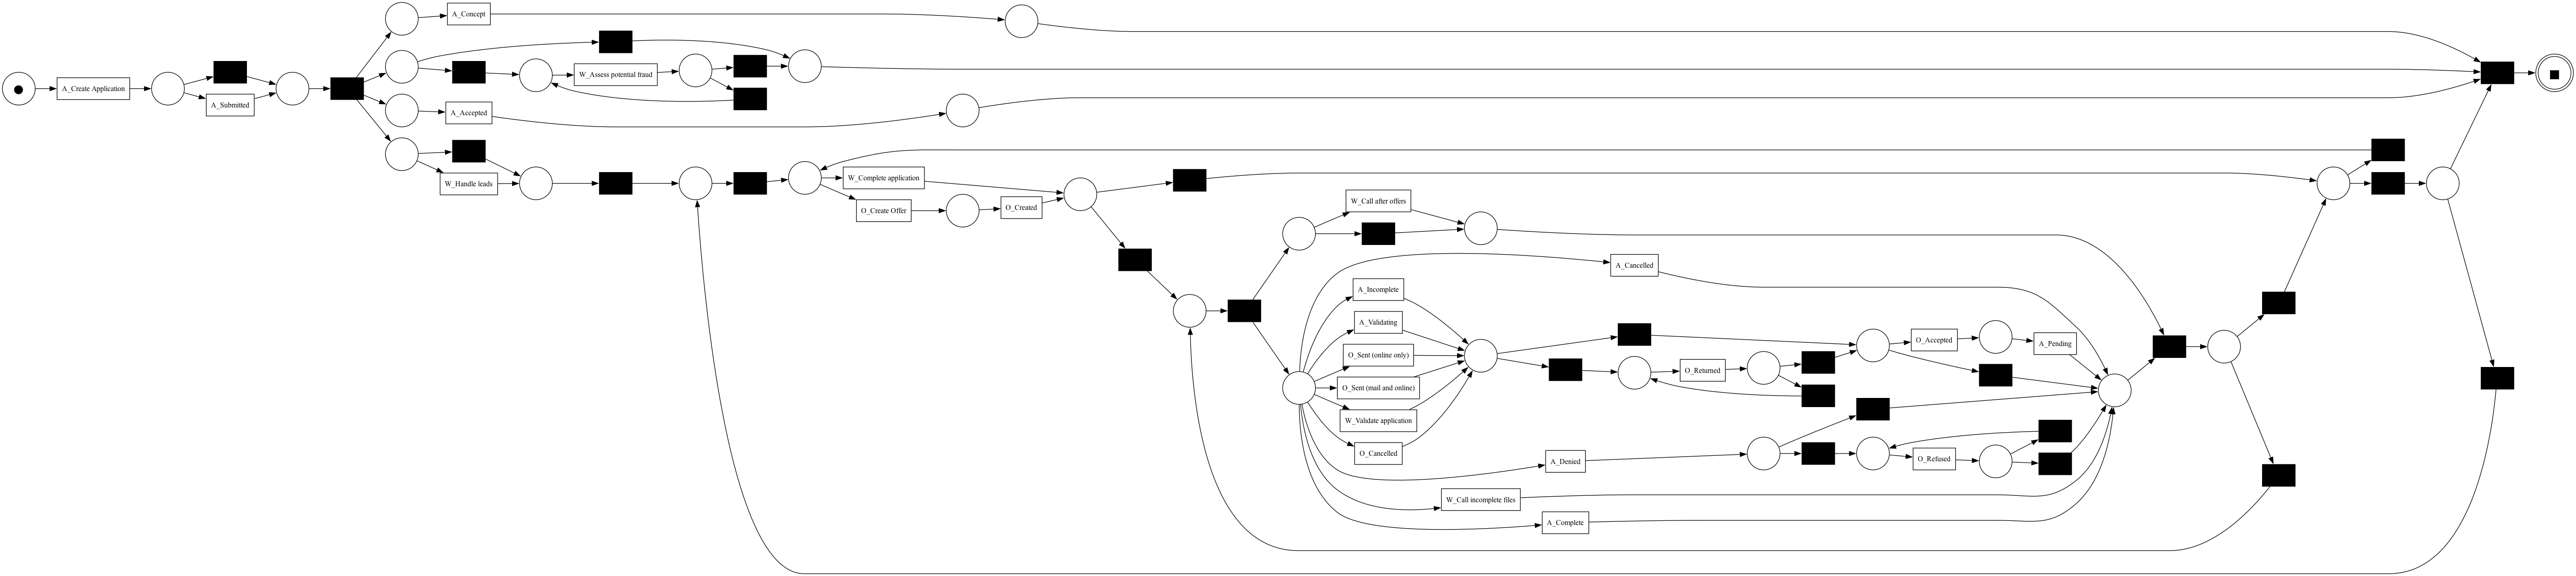


✓ Petri Net gespeichert: output/inductive_default_petri_net.png


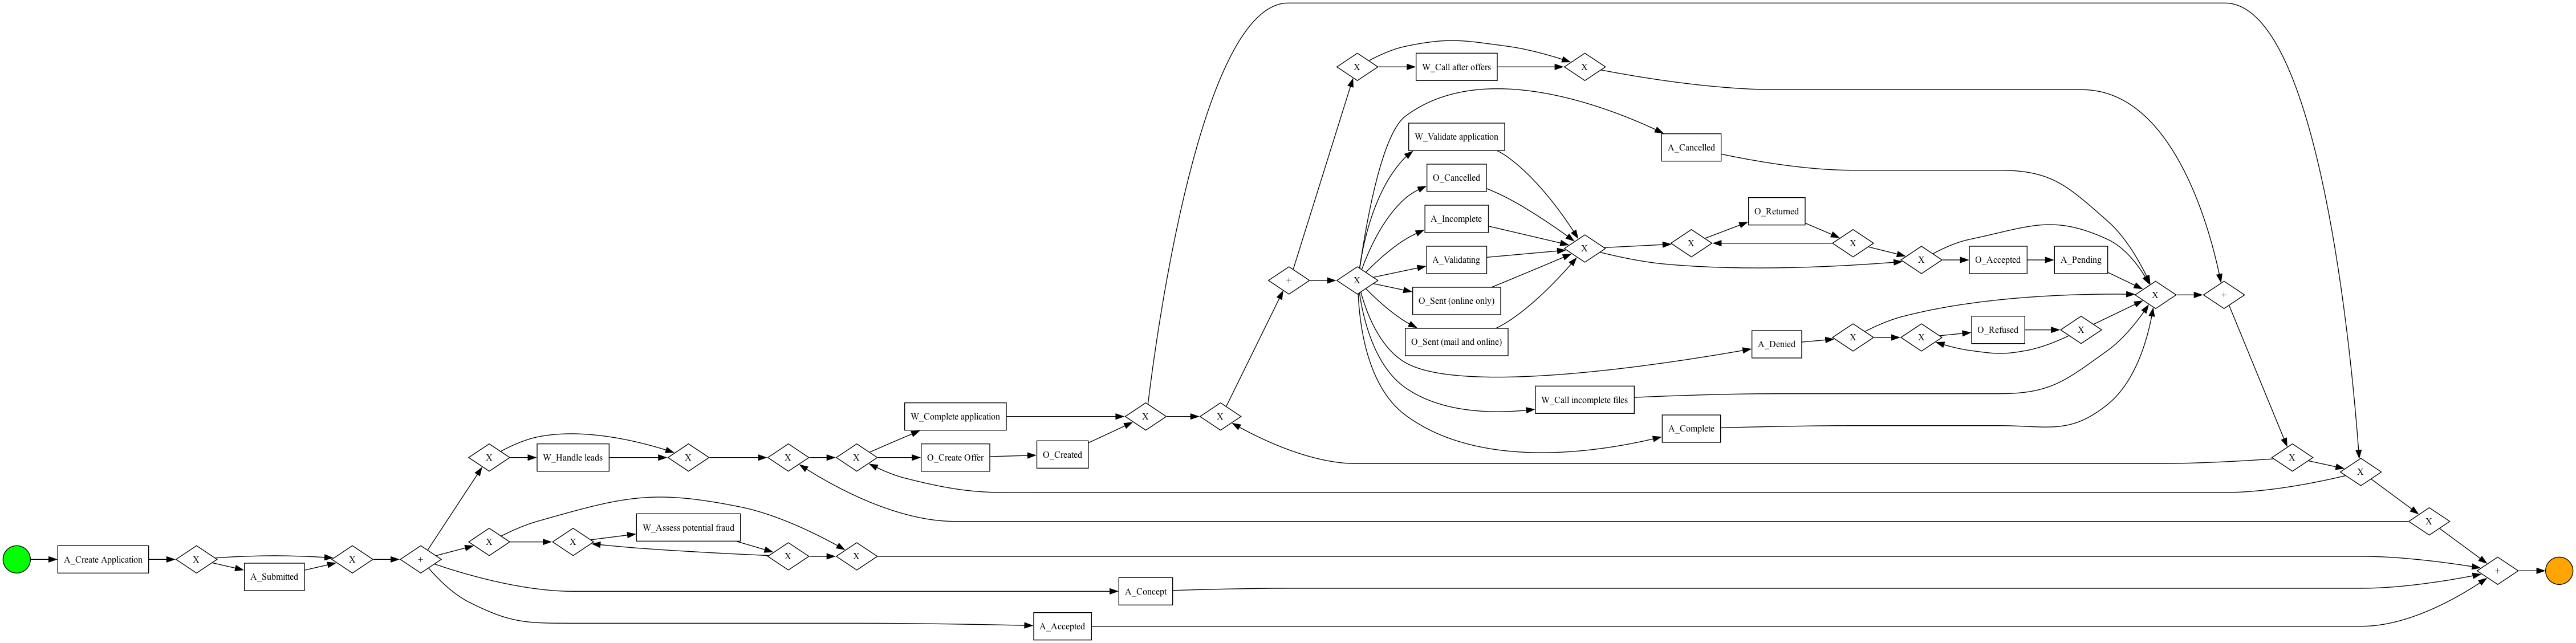

✓ BPMN gespeichert:      output/inductive_default_bpmn.png


In [ ]:
# ── Inductive Miner Discovery ──────────────────────────────────────────────────
print("Discovering Inductive Miner model...")
net_ind, im_ind, fm_ind = pm4py.discover_petri_net_inductive(log_closed)
print("Inductive Miner: done")

# ── Metriken via evaluate_model ────────────────────────────────────────────────
results_ind = evaluate_model(
    "Inductive Miner (Default)",
    net_ind, im_ind, fm_ind,
    log_closed
)

# ── Visualization & export ────────────────────────────────────────────────────
os.makedirs("output", exist_ok=True)

pm4py.view_petri_net(net_ind, im_ind, fm_ind)
pm4py.save_vis_petri_net(net_ind, im_ind, fm_ind, "output/inductive_default_petri_net.png")
print("\n✓ Petri Net gespeichert: output/inductive_default_petri_net.png")

bpmn_ind = pm4py.convert_to_bpmn(net_ind, im_ind, fm_ind)
pm4py.view_bpmn(bpmn_ind)
pm4py.save_vis_bpmn(bpmn_ind, "output/inductive_default_bpmn.png")
print("✓ BPMN gespeichert:      output/inductive_default_bpmn.png")

Same for Heuristic Miner


In [ ]:
# ── Heuristic Miner Discovery ──────────────────────────────────────────────────
print("Discovering Heuristic Miner model...")
# 1. Heuristics Net entdecken
heu_net = pm4py.discover_heuristics_net(log_closed)

# 2. Umwandlung des Heuristics Net in ein Petri-Netz
from pm4py.objects.conversion.heuristics_net import converter as hn_converter
net_heu, im_heu, fm_heu = hn_converter.apply(heu_net)

print("Heuristic Miner: done")

# ── Metriken via evaluate_model ────────────────────────────────────────────────
results_heu = evaluate_model(
    "Heuristic Miner (Default)",
    net_heu, im_heu, fm_heu,
    log_closed
)

# ── Visualization & export ────────────────────────────────────────────────────
os.makedirs("output", exist_ok=True)

pm4py.view_petri_net(net_heu, im_heu, fm_heu)
pm4py.save_vis_petri_net(net_heu, im_heu, fm_heu, "output/heuristic_default_petri_net.png")
print("\n✓ Petri Net gespeichert: output/heuristic_default_petri_net.png")

bpmn_heu = pm4py.convert_to_bpmn(net_heu, im_heu, fm_heu)
pm4py.view_bpmn(bpmn_heu)
pm4py.save_vis_bpmn(bpmn_heu, "output/heuristic_default_bpmn.png")
print("✓ BPMN gespeichert:      output/heuristic_default_bpmn.png")

Discovering Heuristic Miner model...


NameError: name 'pm4py' is not defined

Elbow chart for better understanding of variant coverage


Total Cases: 31411
Unique Variants: 5562


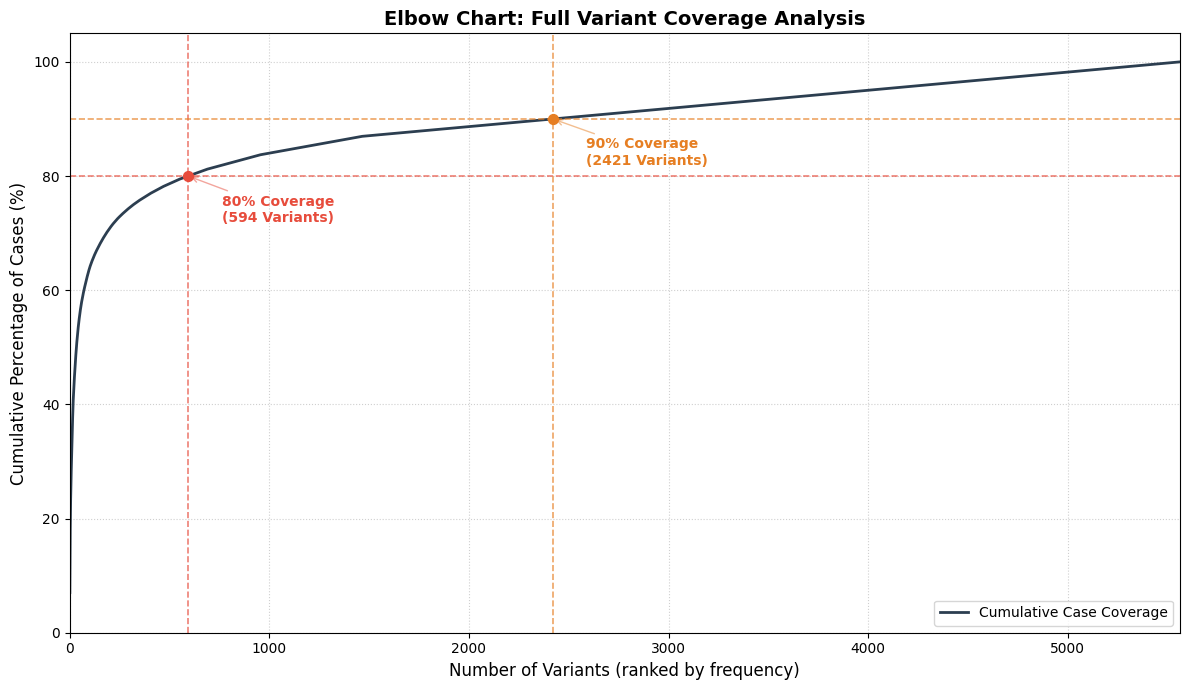


--- Coverage Summary ---
80% of all cases are covered by the top 594 variants.
90% of all cases are covered by the top 2421 variants.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pm4py
import os

# --- 1. Variant Analysis ---
# Extract variant frequencies
variants = pm4py.get_variants_as_tuples(log_closed)
variant_counts = sorted(variants.values(), reverse=True)

# Calculate cumulative share (0 to 100%)
total_cases = sum(variant_counts)
cumulative_coverage = np.cumsum(variant_counts) / total_cases * 100

print(f"Total Cases: {total_cases}")
print(f"Unique Variants: {len(variant_counts)}")

# --- 2. Create Elbow Chart ---
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the main curve over ALL variants
x_range = range(1, len(cumulative_coverage) + 1)
ax.plot(
    x_range,
    cumulative_coverage,
    color='#2c3e50', 
    linewidth=2,
    label='Cumulative Case Coverage'
)

# --- 3. Highlight 80% and 90% Thresholds ---
# Focus on the requested threshold marks
thresholds = [80, 90]
colors = ['#e74c3c', '#e67e22'] # Red for 80%, orange for 90%

for pct, color in zip(thresholds, colors):
    # Find the index where the threshold is reached
    num_variants = np.searchsorted(cumulative_coverage, pct) + 1
    
    # Draw horizontal and vertical lines
    ax.axhline(y=pct, color=color, linestyle='--', alpha=0.7, linewidth=1.2)
    ax.axvline(x=num_variants, color=color, linestyle='--', alpha=0.7, linewidth=1.2)
    
    # Mark the point
    ax.scatter(num_variants, pct, color=color, s=50, zorder=5)
    
    # Label directly at the intersection point
    ax.annotate(
        f'{pct}% Coverage\n({num_variants} Variants)',
        xy=(num_variants, pct),
        xytext=(num_variants + (len(cumulative_coverage) * 0.03), pct - 8),
        fontsize=10,
        fontweight='bold',
        color=color,
        arrowprops=dict(arrowstyle='->', color=color, alpha=0.5)
    )

# --- 4. Chart Formatting ---
ax.set_xlabel('Number of Variants (ranked by frequency)', fontsize=12)
ax.set_ylabel('Cumulative Percentage of Cases (%)', fontsize=12)
ax.set_title('Elbow Chart: Full Variant Coverage Analysis', fontsize=14, fontweight='bold')

# X-axis now shows the full range of all variants
ax.set_xlim(0, len(cumulative_coverage))
ax.set_ylim(0, 105)

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right')

plt.tight_layout()

# --- 5. Save and Export ---
os.makedirs("output", exist_ok=True)
plt.savefig('output/elbow_chart_full.png', dpi=300)
plt.show()

# --- 6. Summary Output ---
print("\n--- Coverage Summary ---")
for pct in thresholds:
    idx = np.searchsorted(cumulative_coverage, pct) + 1
    print(f"{pct}% of all cases are covered by the top {idx} variants.")

80% Coverage = 10,7% of all cases Inductive

── Variant Filtering ──
Total variants:                  24
Variants after filter:           24
Cases before filtering:          31411
Cases removed:                   5920
Cases remaining after filtering: 25491
Events remaining:                346327

Discovering Inductive Miner (top 80% variants)...
done

Evaluating on log_closed (full log)...


replaying log with TBR, completed traces :: 100%|██████████| 5562/5562 [00:06<00:00, 863.62it/s] 



── Inductive Miner (Top 80% Varianten) ──
Places               53
Transitions          77
Silent Trans.        53
Arcs                 168
Fitness              0.9999
Precision            0.3186
Generalization       0.9716
Simplicity(PM4Py)    0.6311
CFC                  64
SSA                  0.2


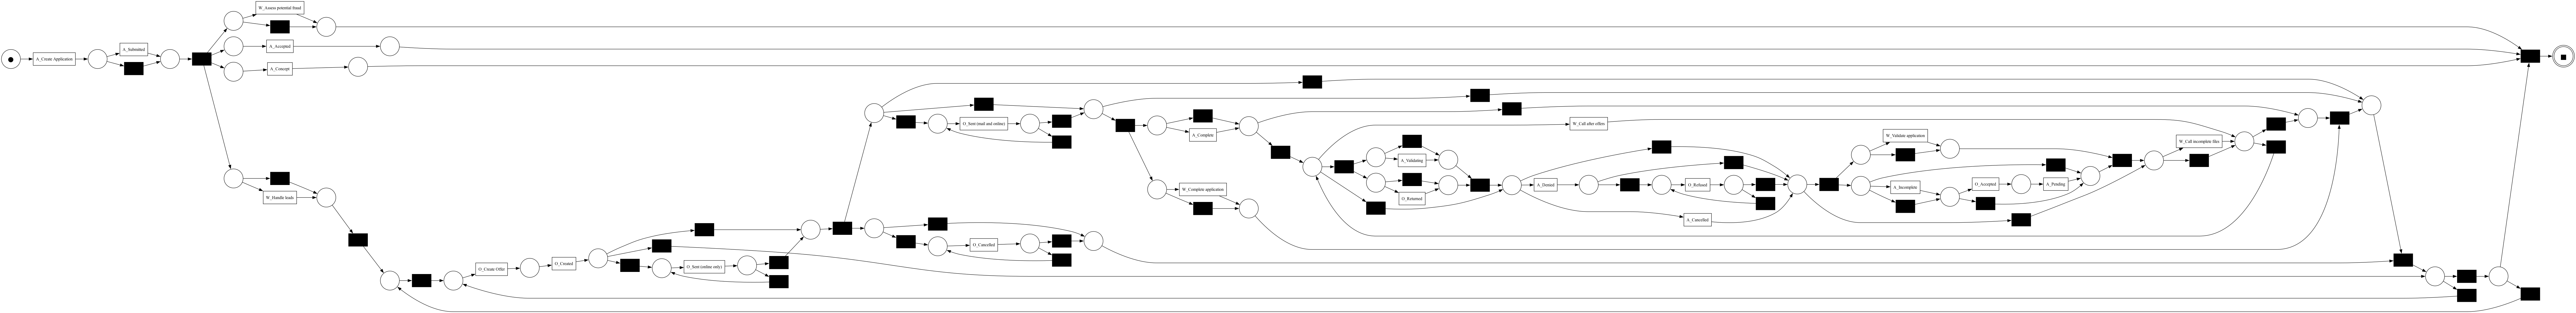


✓ Petri Net saved: output/inductive_80var_petri_net.png


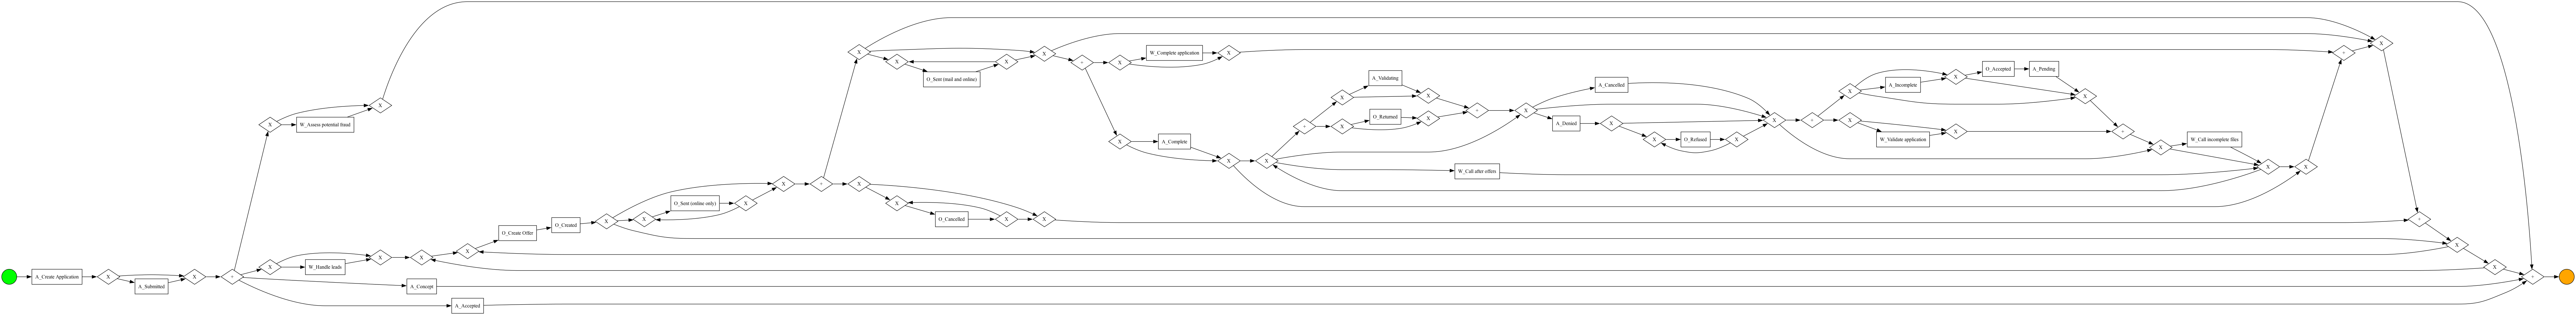

✓ BPMN saved:      output/inductive_80var_bpmn.png


In [ ]:
from pm4py.algo.filtering.log.variants import variants_filter
import os

# ── Top 80% variant filter (= 10.7% of all variants = 593 variants) ──────────
log_filtered_80 = pm4py.convert_to_dataframe(
    variants_filter.filter_log_variants_percentage(
        pm4py.convert_to_event_log(log_closed),
        percentage=0.8
    )
)

print(f"── Variant Filtering ──")
print(f"Total variants:                  {log_closed['concept:name'].nunique()}")
print(f"Variants after filter:           {log_filtered_80['concept:name'].nunique()}")
print(f"Cases before filtering:          {log_closed[CASE_COL].nunique()}")
print(f"Cases removed:                   {log_closed[CASE_COL].nunique() - log_filtered_80[CASE_COL].nunique()}")
print(f"Cases remaining after filtering: {log_filtered_80[CASE_COL].nunique()}")
print(f"Events remaining:                {len(log_filtered_80)}")

# ── Inductive Miner training on top 80% variants ─────────────────────────────
print("\nDiscovering Inductive Miner (top 80% variants)...")
net_80, im_80, fm_80 = pm4py.discover_petri_net_inductive(log_filtered_80)
print("done")

# ── Metrics on full log_closed ───────────────────────────────────────────────
print("\nEvaluating on log_closed (full log)...")
results_80 = evaluate_model(
    "Inductive Miner (Top 80% Varianten)",
    net_80, im_80, fm_80,
    log_closed
)

# ── Visualization & export ───────────────────────────────────────────────────
os.makedirs("output", exist_ok=True)

pm4py.view_petri_net(net_80, im_80, fm_80)
pm4py.save_vis_petri_net(net_80, im_80, fm_80, "output/inductive_80var_petri_net.png")
print("\n✓ Petri Net saved: output/inductive_80var_petri_net.png")

bpmn_80 = pm4py.convert_to_bpmn(net_80, im_80, fm_80)
pm4py.view_bpmn(bpmn_80)
pm4py.save_vis_bpmn(bpmn_80, "output/inductive_80var_bpmn.png")
print("✓ BPMN saved:      output/inductive_80var_bpmn.png")

80% Coverage = 10,7% of all cases heuristic

── Variant Filtering (Heuristic Miner) ──
Cases remaining after filtering: 25491

Discovering Heuristic Miner (top 80% variants)...
done

Evaluating on log_closed (full log)...


replaying log with TBR, completed traces :: 100%|██████████| 5562/5562 [00:07<00:00, 772.28it/s]



── Heuristic Miner (Top 80% Varianten) ──
Places               44
Transitions          71
Silent Trans.        47
Arcs                 161
Fitness              0.8447
Precision            0.9989
Generalization       0.9187
Simplicity(PM4Py)    0.5556
CFC                  66
SSA                  0.2261


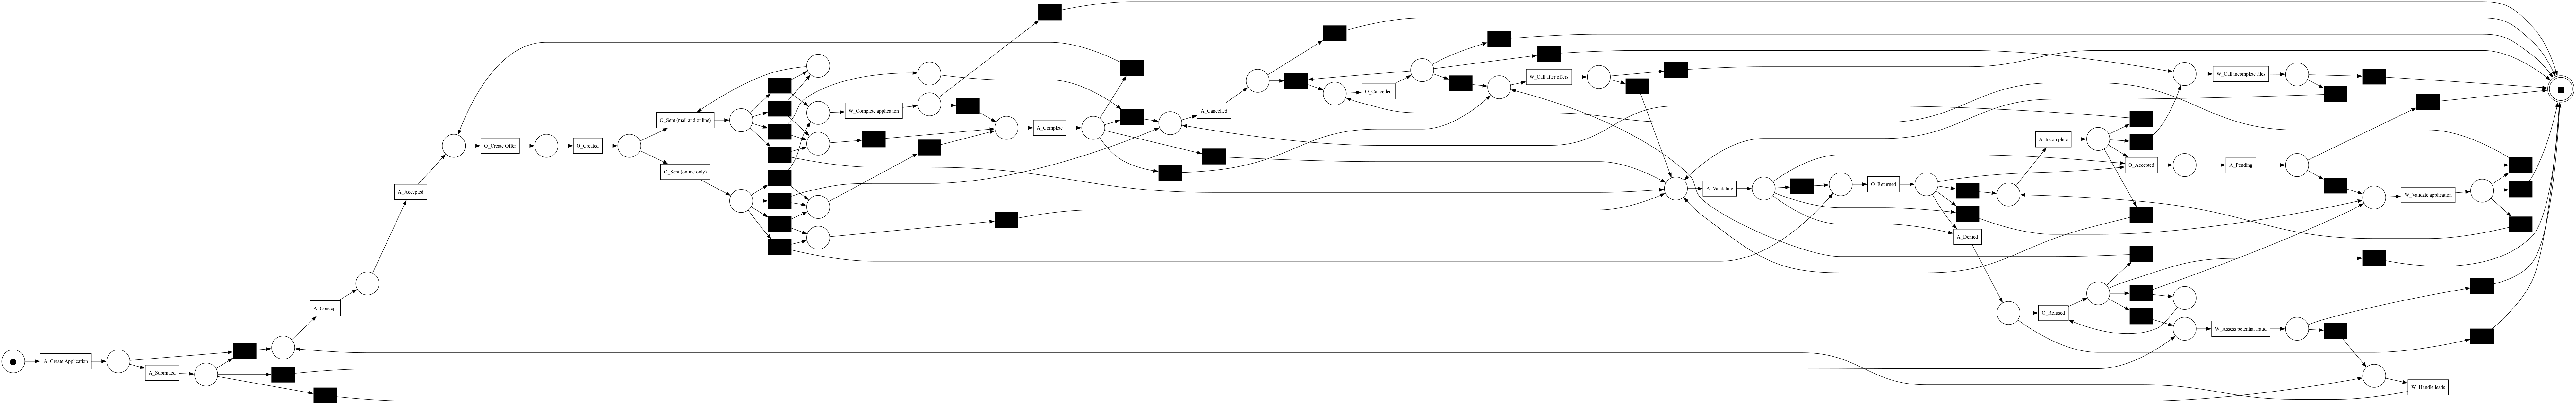


✓ Petri Net saved: output/heuristic_80var_petri_net.png


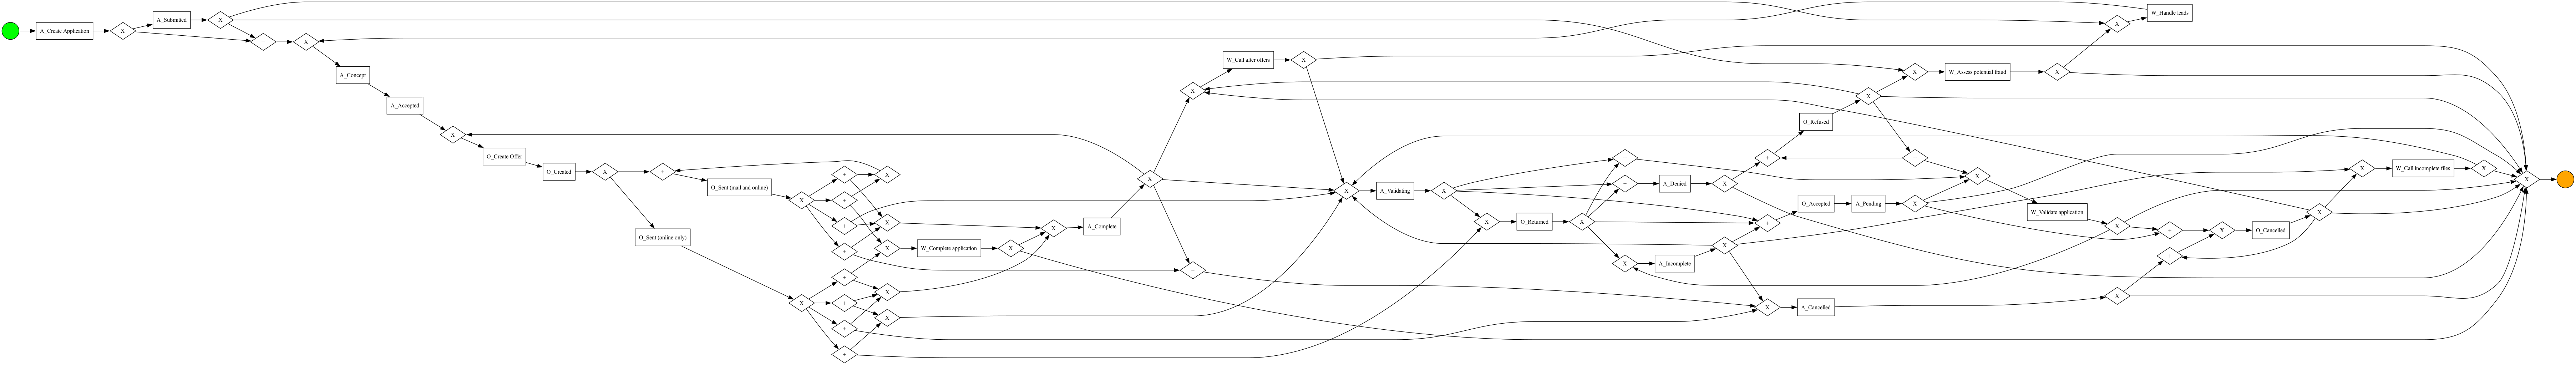

✓ BPMN saved:      output/heuristic_80var_bpmn.png


In [ ]:
from pm4py.objects.conversion.heuristics_net import converter as hn_converter

# ── Top 80% variant filter ───────────────────────────────────────────────────
# (The filter part stays the same to work consistently on the same data)
log_filtered_80 = pm4py.convert_to_dataframe(
    variants_filter.filter_log_variants_percentage(
        pm4py.convert_to_event_log(log_closed),
        percentage=0.8
    )
)

print(f"── Variant Filtering (Heuristic Miner) ──")
print(f"Cases remaining after filtering: {log_filtered_80[CASE_COL].nunique()}")

# ── Heuristic Miner training on top 80% variants ─────────────────────────────
print("\nDiscovering Heuristic Miner (top 80% variants)...")

# Discovery and direct conversion to Petri net (net, im, fm)
heu_net_80 = pm4py.discover_heuristics_net(log_filtered_80)
net_heu_80, im_heu_80, fm_heu_80 = hn_converter.apply(heu_net_80)

print("done")

# ── Metrics on full log_closed ───────────────────────────────────────────────
print("\nEvaluating on log_closed (full log)...")
results_heu_80 = evaluate_model(
    "Heuristic Miner (Top 80% Varianten)",
    net_heu_80, im_heu_80, fm_heu_80,
    log_closed
)

# ── Visualization & export ───────────────────────────────────────────────────
os.makedirs("output", exist_ok=True)

# Petri net visualization & export
pm4py.view_petri_net(net_heu_80, im_heu_80, fm_heu_80)
pm4py.save_vis_petri_net(net_heu_80, im_heu_80, fm_heu_80, "output/heuristic_80var_petri_net.png")
print("\n✓ Petri Net saved: output/heuristic_80var_petri_net.png")

# BPMN visualization & export
bpmn_heu_80 = pm4py.convert_to_bpmn(net_heu_80, im_heu_80, fm_heu_80)
pm4py.view_bpmn(bpmn_heu_80)
pm4py.save_vis_bpmn(bpmn_heu_80, "output/heuristic_80var_bpmn.png")
print("✓ BPMN saved:      output/heuristic_80var_bpmn.png")

####  threshold sweep — extended analysis output


In [ ]:
import os
import pandas as pd

results = []

for threshold in [0.3, 0.5, 0.7, 0.9]:
    print(f"\n{'='*70}")
    print(f"Threshold: {threshold}")
    print(f"{'='*70}")
    
    # Train model
    net_t, im_t, fm_t = pm4py.discover_petri_net_inductive(
        log_filtered_80,
        noise_threshold=threshold
    )
    
    # All metrics via evaluate_model (CFC, SSA, Fitness, Precision, etc.)
    metrics = evaluate_model(
        f"Inductive Miner (noise_threshold={threshold})",
        net_t, im_t, fm_t,
        log_closed
    )
    
    # ── Activity analysis in addition to standard evaluation ─────────────────
    log_acts = set(log_filtered_80['concept:name'].unique())
    modeled_acts = {t.label for t in net_t.transitions if t.label is not None}
    missing_in_model = log_acts - modeled_acts
    
    # Which activities are "optional" (have silent siblings in the same place)?
    optional_acts = set()
    for trans in net_t.transitions:
        if trans.label is None:
            continue
        for arc in trans.in_arcs:
            place = arc.source
            siblings = [a.target for a in place.out_arcs if a.target != trans]
            if any(sib.label is None for sib in siblings):
                optional_acts.add(trans.label)
                break
    
    # Count decision points
    n_real_dp = 0
    n_phantom_dp = 0
    for p in net_t.places:
        out_trans = [arc.target for arc in p.out_arcs]
        if len(out_trans) > 1:
            labeled_branches = [t for t in out_trans if t.label is not None]
            if len(labeled_branches) >= 1:
                n_real_dp += 1
            else:
                n_phantom_dp += 1
    
    # Additional output
    print(f"\n── Activity Coverage ──")
    print(f"Labeled transitions:   {len(modeled_acts)} / {len(log_acts)} in log")
    print(f"Real Decision Points:  {n_real_dp}")
    print(f"Phantom DPs (only τ):  {n_phantom_dp}")
    
    if missing_in_model:
        print(f"\n❌ Activities MISSING in model ({len(missing_in_model)}):")
        for act in sorted(missing_in_model):
            n = (log_closed['concept:name'] == act).sum()
            pct = 100 * n / len(log_closed)
            print(f"    {act}: {n} Events ({pct:.2f}%)")
    else:
        print(f"\n✓ All {len(log_acts)} activities present in model")
    
    if optional_acts:
        print(f"\n⚠ Activities in optional/loop wrapper ({len(optional_acts)}):")
        for act in sorted(optional_acts):
            n = (log_closed['concept:name'] == act).sum()
            pct = 100 * n / len(log_closed)
            print(f"    {act}: {n} events ({pct:.2f}%) — modelled as optional")
    
    # Aggregated row for comparison table
    f1 = (2 * metrics['Fitness'] * metrics['Precision'] / 
          (metrics['Fitness'] + metrics['Precision'])
          if (metrics['Fitness'] + metrics['Precision']) > 0 else 0)
    
    results.append({
        'threshold':       threshold,
        'Fitness':         metrics['Fitness'],
        'Precision':       metrics['Precision'],
        'F1':              round(f1, 4),
        'Generalization':  metrics['Generalization'],
        'Simplicity':      metrics['Simplicity(PM4Py)'],
        'CFC':             metrics['CFC'],
        'SSA':             metrics['SSA'],
        'Places':          metrics['Places'],
        'Transitions':     metrics['Transitions'],
        'Silent':          metrics['Silent Trans.'],
        'Missing':         len(missing_in_model),
        'Optional':        len(optional_acts),
        'Real_DPs':        n_real_dp,
        'Phantom_DPs':     n_phantom_dp,
    })
    
    # Petri Net and BPMN only for threshold=0.7
    if threshold == 0.7:
        os.makedirs("output", exist_ok=True)
        
        pm4py.view_petri_net(net_t, im_t, fm_t)
        pm4py.save_vis_petri_net(
            net_t, im_t, fm_t,
            "output/inductive_07_petri_net.png"
        )
        print("\n✓ Petri Net saved: output/inductive_07_petri_net.png")
        
        bpmn_t = pm4py.convert_to_bpmn(net_t, im_t, fm_t)
        pm4py.view_bpmn(bpmn_t)
        pm4py.save_vis_bpmn(bpmn_t, "output/inductive_07_bpmn.png")
        print("✓ BPMN saved:      output/inductive_07_bpmn.png")

# ── Comparison table ──────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("VERGLEICHSTABELLE")
print(f"{'='*70}")

df_results = pd.DataFrame(results).set_index('threshold')
display(df_results)

# Export as CSV for the report
df_results.to_csv("output/threshold_comparison.csv")
print(f"\n✓ Comparison table saved: output/threshold_comparison.csv")

Heuristic Miner with varying dependency thresholds


In [ ]:
import os
import pandas as pd
import pm4py
from pm4py.objects.conversion.heuristics_net import converter as hn_converter

# ── Dependency-Threshold-Sweep ────────────────────────────────────────────────
# AND- and loop-threshold remain at default (0.65 and 0.5), only dependency_threshold
# is varied to measure its effect in isolation.

dep_values = [0.3, 0.5, 0.7, 0.9, 0.99]
results_sweep = []

os.makedirs("output", exist_ok=True)

for dep_t in dep_values:
    print(f"\n{'='*60}")
    print(f"── Discovery with dependency_threshold = {dep_t} ──")
    print(f"{'='*60}")

    # 1. Discovery
    heu_net_t = pm4py.discover_heuristics_net(
        log_filtered_80,
        dependency_threshold=dep_t,
        # and_threshold und loop_two_threshold auf Default
    )

    # 2. Convert to Petri net
    net_t, im_t, fm_t = hn_converter.apply(heu_net_t)

    # 3. Metrics
    model_name = f"Heuristic Miner (dep={dep_t})"
    results_t = evaluate_model(
        model_name,
        net_t, im_t, fm_t,
        log_closed,
    )

    # Collect results for comparison table
    results_sweep.append({
        'dep': dep_t,
        **results_t,
    })

    # 4. Visualization & export
    suffix = f"dep{str(dep_t).replace('.', '')}"

    file_path_pn = f"output/heuristic_{suffix}_petri_net.png"
    pm4py.save_vis_petri_net(net_t, im_t, fm_t, file_path_pn)

    file_path_bpmn = f"output/heuristic_{suffix}_bpmn.png"
    bpmn_t = pm4py.convert_to_bpmn(net_t, im_t, fm_t)
    pm4py.save_vis_bpmn(bpmn_t, file_path_bpmn)

    print(f"✓ Exportiert: heuristic_{suffix}_petri_net.png + _bpmn.png")

# ── Comparison table ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"── Comparison of all dependency_threshold values ──")
print(f"{'='*60}")

df_sweep = pd.DataFrame(results_sweep)
# Remove algorithm column, move dep to front
cols = ['dep'] + [c for c in df_sweep.columns if c not in ('dep', 'Algorithmus')]
df_sweep = df_sweep[cols]

print(df_sweep.to_string(index=False))

# Optional: export as CSV for the report
df_sweep.to_csv("output/dep_threshold_sweep.csv", index=False)
print("\n✓ Comparison table saved: output/dep_threshold_sweep.csv")

print("\n── Sweep completed ──")


── Discovery with dependency_threshold = 0.3 ──


replaying log with TBR, completed traces :: 100%|██████████| 5562/5562 [00:13<00:00, 405.46it/s]



── Heuristic Miner (dep=0.3) ──
Places               44
Transitions          71
Silent Trans.        47
Arcs                 161
Fitness              0.8448
Precision            0.9988
Generalization       0.9063
Simplicity(PM4Py)    0.5556
CFC                  66
SSA                  0.2261
✓ Exportiert: heuristic_dep03_petri_net.png + _bpmn.png

── Discovery with dependency_threshold = 0.5 ──


replaying log with TBR, completed traces :: 100%|██████████| 5562/5562 [00:07<00:00, 725.93it/s]



── Heuristic Miner (dep=0.5) ──
Places               44
Transitions          71
Silent Trans.        47
Arcs                 161
Fitness              0.8448
Precision            0.9988
Generalization       0.9063
Simplicity(PM4Py)    0.5556
CFC                  66
SSA                  0.2261
✓ Exportiert: heuristic_dep05_petri_net.png + _bpmn.png

── Discovery with dependency_threshold = 0.7 ──


...


── Heuristic Miner (dep=0.7) ──
Places               44
Transitions          72
Silent Trans.        48
Arcs                 163
Fitness              0.8456
Precision            0.9988
Generalization       0.9073
Simplicity(PM4Py)    0.5524
CFC                  67
SSA                  0.2241
✓ Exportiert: heuristic_dep07_petri_net.png + _bpmn.png

── Discovery with dependency_threshold = 0.9 ──


replaying log with TBR, completed traces :: 100%|██████████| 5562/5562 [00:11<00:00, 474.03it/s] 



── Heuristic Miner (dep=0.9) ──
Places               41
Transitions          68
Silent Trans.        44
Arcs                 155
Fitness              0.8471
Precision            0.9984
Generalization       0.9253
Simplicity(PM4Py)    0.5423
CFC                  65
SSA                  0.2385
✓ Exportiert: heuristic_dep09_petri_net.png + _bpmn.png

── Discovery with dependency_threshold = 0.99 ──


replaying log with TBR, completed traces :: 100%|██████████| 5562/5562 [00:07<00:00, 734.15it/s] 



── Heuristic Miner (dep=0.99) ──
Places               37
Transitions          58
Silent Trans.        36
Arcs                 131
Fitness              0.8483
Precision            0.9992
Generalization       0.9294
Simplicity(PM4Py)    0.5689
CFC                  54
SSA                  0.2526
✓ Exportiert: heuristic_dep099_petri_net.png + _bpmn.png

── Comparison of all dependency_threshold values ──
 dep  Places  Transitions  Silent Trans.  Arcs  Fitness  Precision  Generalization  Simplicity(PM4Py)  CFC    SSA
0.30      44           71             47   161   0.8448     0.9988          0.9063             0.5556   66 0.2261
0.50      44           71             47   161   0.8448     0.9988          0.9063             0.5556   66 0.2261
0.70      44           72             48   163   0.8456     0.9988          0.9073             0.5524   67 0.2241
0.90      41           68             44   155   0.8471     0.9984          0.9253             0.5423   65 0.2385
0.99      37           58

Petri Net Reduction with Heuristic miner
 

In [ ]:
import os
import pm4py
from pm4py.objects.conversion.heuristics_net import converter as hn_converter
from pm4py.objects.petri_net.utils import reduction

# Define fixed parameters
dep_t = 0.99
and_t = 0.65  # default value

print(f"── Starting discovery with dependency threshold: {dep_t} ──")

# 1. Discover the Heuristics Net
heu_net_t = pm4py.discover_heuristics_net(
    log_filtered_80,
    dependency_threshold=dep_t,
    and_threshold=and_t,
)

# 2. Convert to Petri net
net_t, im_t, fm_t = hn_converter.apply(heu_net_t)

# ── Diagnosis: activities and structure before reduction ──────────────────────
visible_acts = {t.label for t in net_t.transitions if t.label is not None}
silent_count = sum(1 for t in net_t.transitions if t.label is None)
acts_in_log = set(log_filtered_80['concept:name'].unique())
missing = acts_in_log - visible_acts

print(f"\n── Activity Diagnosis (before reduction) ──")
print(f"Activities in log:           {len(acts_in_log)}")
print(f"Visible transitions in net:    {len(visible_acts)}")
print(f"Silent Transitions (τ):       {silent_count}")
print(f"Places:                       {len(net_t.places)}")
print(f"Arcs:                         {len(net_t.arcs)}")
if missing:
    print(f"⚠ Missing activities:          {missing}")

# ── FSP reduction ────────────────────────────────────────────────────────────
# Reduction rules remove redundant structures (e.g., unnecessary τ-transitions
# and sequence places) WITHOUT changing the model behaviour.
# Fitness and precision remain identical; simplicity and CFC improve.
print(f"\n── FSP Reduction ──")
net_red, im_red, fm_red = reduction.apply_simple_reduction(net_t), im_t, fm_t

silent_after = sum(1 for t in net_red.transitions if t.label is None)
print(f"Places:        {len(net_t.places)} → {len(net_red.places)}")
print(f"Transitions:   {len(net_t.transitions)} → {len(net_red.transitions)}")
print(f"  thereof τ:   {silent_count} → {silent_after}")
print(f"Arcs:          {len(net_t.arcs)} → {len(net_red.arcs)}")

# ── Metrics (on reduced net) ─────────────────────────────────────────────────
model_name = f"Heuristic Miner (Dep={dep_t}, FSP-reduced)"
results_t = evaluate_model(
    model_name,
    net_red, im_red, fm_red,
    log_closed,
)

# ── Visualization & export ───────────────────────────────────────────────────
os.makedirs("output", exist_ok=True)
suffix = f"dep{str(dep_t).replace('.', '')}_reduced"

# Petri Net
file_path_pn = f"output/heuristic_{suffix}_petri_net.png"
pm4py.view_petri_net(net_red, im_red, fm_red)
pm4py.save_vis_petri_net(net_red, im_red, fm_red, file_path_pn)
print(f"\n✓ Petri Net saved: {file_path_pn}")

# BPMN
file_path_bpmn = f"output/heuristic_{suffix}_bpmn.png"
bpmn_t = pm4py.convert_to_bpmn(net_red, im_red, fm_red)
pm4py.view_bpmn(bpmn_t)
pm4py.save_vis_bpmn(bpmn_t, file_path_bpmn)
print(f"✓ BPMN saved:      {file_path_bpmn}")

print("\n── Analysis completed ──")

Activity Filtering


In [ ]:
import os
import pm4py
from pm4py.objects.conversion.heuristics_net import converter as hn_converter

# ── Step 1: Activity frequency filter (10% threshold) ────────────────────────
# Activities occurring in fewer than 10% of cases are treated as noise
# and removed (cf. Heuristic Miner philosophy: frequency-based filtering).

total_cases = log_filtered_80['case:concept:name'].nunique()
threshold = total_cases * 0.10  # present in at least 10% of cases

# Frequency per activity at case level (not event level)
acts_per_case = log_filtered_80.groupby('concept:name')['case:concept:name'].nunique()

keep_activities = set(acts_per_case[acts_per_case >= threshold].index)
removed_activities = set(acts_per_case.index) - keep_activities

print(f"── Activity Frequency Filter (≥10% of cases) ──")
print(f"Total cases:                {total_cases}")
print(f"Threshold:                  {threshold:.0f} cases (10%)")
print(f"Retained activities:        {len(keep_activities)}")
print(f"Removed activities:         {len(removed_activities)}")
if removed_activities:
    print(f"\nRemoved activities in detail:")
    for act in sorted(removed_activities):
        n = acts_per_case[act]
        pct = 100 * n / total_cases
        print(f"  {act}: {n} Cases ({pct:.2f}%)")

log_freq_filtered = log_filtered_80[
    log_filtered_80['concept:name'].isin(keep_activities)
].copy()

print(f"\nEvents vor Filter:          {len(log_filtered_80)}")
print(f"Events after filter:        {len(log_freq_filtered)}")
print(f"Reduktion:                  {100 * (len(log_filtered_80) - len(log_freq_filtered)) / len(log_filtered_80):.2f}%")

# ── Step 2: Heuristic Miner with standard thresholds ─────────────────────────
dep_t = 0.99
and_t = 0.65

print(f"\n── Heuristic Miner: dep={dep_t}, and={and_t} ──")

heu_net_t = pm4py.discover_heuristics_net(
    log_freq_filtered,
    dependency_threshold=dep_t,
    and_threshold=and_t,
)

net_t, im_t, fm_t = hn_converter.apply(heu_net_t)

# ── Step 3: Diagnosis ────────────────────────────────────────────────────────
visible_acts = {t.label for t in net_t.transitions if t.label is not None}
silent_count = sum(1 for t in net_t.transitions if t.label is None)
acts_in_log = set(log_freq_filtered['concept:name'].unique())
missing = acts_in_log - visible_acts

print(f"\n── Activity Diagnosis ──")
print(f"Activities in (filtered) log:      {len(acts_in_log)}")
print(f"Visible transitions in net:        {len(visible_acts)}")
print(f"Silent Transitions (τ):            {silent_count}")
print(f"Places:                            {len(net_t.places)}")
print(f"Arcs:                              {len(net_t.arcs)}")
if missing:
    print(f"⚠ Missing activities:             {missing}")

# ── Step 4: Metrics ──────────────────────────────────────────────────────────
# Important: evaluate against log_freq_filtered, not log_closed!
# Otherwise activities may appear in the test log that the model does not know.
model_name = f"Heuristic Miner (freq-filtered ≥5%, Dep={dep_t})"
results_t = evaluate_model(
    model_name,
    net_t, im_t, fm_t,
    log_freq_filtered,
)

# ── Step 5: Visualization & export ───────────────────────────────────────────
os.makedirs("output", exist_ok=True)
suffix = f"freq05_dep{str(dep_t).replace('.', '')}"

file_path_pn = f"output/heuristic_{suffix}_petri_net.png"
pm4py.view_petri_net(net_t, im_t, fm_t)
pm4py.save_vis_petri_net(net_t, im_t, fm_t, file_path_pn)
print(f"\n✓ Petri Net saved: {file_path_pn}")

file_path_bpmn = f"output/heuristic_{suffix}_bpmn.png"
bpmn_t = pm4py.convert_to_bpmn(net_t, im_t, fm_t)
pm4py.view_bpmn(bpmn_t)
pm4py.save_vis_bpmn(bpmn_t, file_path_bpmn)
print(f"✓ BPMN saved:      {file_path_bpmn}")

print("\n── Analysis completed ──")

Consideration


Experimental cells below (rough work)
